# Estimating Isotopy Class Sizes Using the Jacobson–Matthews Markov Chain

Jacobson–Matthews Markov chain to generate reduced Latin squares, and estimate the number of reduced squares in their isotopy classes using the identity:

$P[\text{Shuff}(S) = S] = \frac{1}{k}$

Where $(k)$ is the number of reduced Latin squares in the isotopy class of square $(S)$.

## Step 1: Generate Reduced Latin Squares

We'll use a simplified random Latin square generator and apply a reduction to ensure the first row and column are in natural order.
Note: this is a placeholder for a more robust Jacobson–Matthews implementation.

In [2]:
import numpy as np
import RandomSquareGenerator
import LatinSquares
import matplotlib.pyplot as plt
from numpy.random import permutation

In [3]:
n = 5 
sq = RandomSquareGenerator.rlatin(n,Minmoves=25)
sq.shuffle()
print(sq.store)
print("Reduced Latin Square:")
reduced_square = np.array(LatinSquares.reduce_square(sq.store))
LatinSquares.print_square(reduced_square)

#LatinSquares.print_square(reduced_square)
#reduced_square.shuffle()


[[3 1 4 0 2]
 [4 2 0 1 3]
 [2 4 1 3 0]
 [0 3 2 4 1]
 [1 0 3 2 4]]
Reduced Latin Square:
[1 2 3 4 5]
[2 4 1 5 3]
[3 5 4 2 1]
[4 1 5 3 2]
[5 3 2 1 4]



## Step 2: Shuffle the Square and Estimate $(\frac{1}{k})$

We shuffle a square multiple times and count how often we get the same square back. This frequency estimates $( P = 1/k )$.

In [4]:
def random_isotopy(square):
    n = square.shape[0]

    # Random row permutation
    row_perm = permutation(n)
    square = square[row_perm, :]

    # Random column permutation
    col_perm = permutation(n)
    square = square[:, col_perm]

    # Random symbol permutation
    symbol_perm = permutation(n) + 1
    symbol_map = {i+1: symbol_perm[i] for i in range(n)}
    square = np.vectorize(lambda x: symbol_map[x])(square)

    return square

In [5]:
def estimate_ki(S, T=1000):
    # T = trails, shuffles of the square 
    count_same = 0
    # Reduce Square 
    S_reduced = LatinSquares.reduce_square(S.copy())
    for _ in range(T):
        # Permute 
        transformed = random_isotopy(S.copy())
        # Reduce
        reduced = LatinSquares.reduce_square(transformed)
        if reduced == S_reduced:
            count_same += 1
    p_hat = count_same / T
    return 1 / p_hat if p_hat > 0 else np.inf

## Step 3: Generate Many Squares and Plot Histogram of Estimated $(k)$

We generate many reduced Latin squares and estimate $(k)$ for each. Then we plot the distribution.

In [6]:

def estimate_ki_distribution(n:int,num_squares:int, trials:int):
    ki_estimates = []
    # Total squares 
    for i in range(num_squares):
        square = RandomSquareGenerator.rlatin(n, Minmoves=25)
        square.shuffle()
        S = LatinSquares.reduce_square(square.store)
        ki = estimate_ki(np.array(S), trials)
        ki_estimates.append(ki)
    return ki_estimates

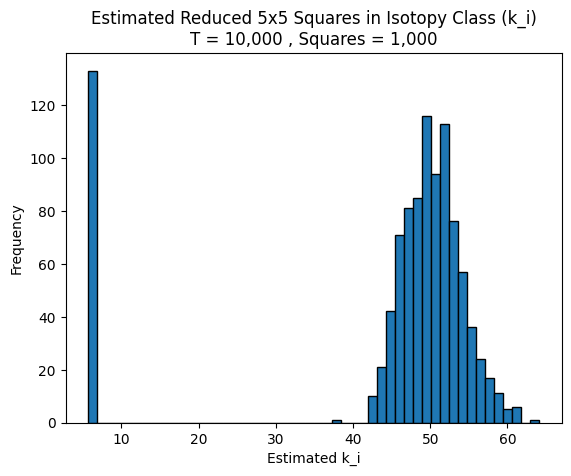

In [84]:
ki_estimates_5x5 = estimate_ki_distribution(5,1000,10000)
# Plot histogram
plt.hist(ki_estimates_5x5, bins=50, edgecolor='black')
plt.xlabel("Estimated k_i")
plt.ylabel("Frequency")
plt.title(f"Estimated Reduced 5x5 Squares in Isotopy Class (k_i)\nT = 10,000 , Squares = 1,000")
plt.show()

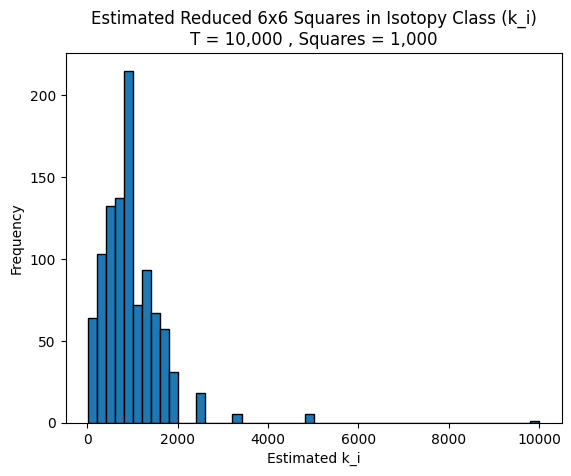

In [85]:
ki_estimates_6x6 = estimate_ki_distribution(6,1000,10000)
# Plot histogram
plt.hist(ki_estimates_6x6, bins=50, edgecolor='black')
plt.xlabel("Estimated k_i")
plt.ylabel("Frequency")
plt.title(f"Estimated Reduced 6x6 Squares in Isotopy Class (k_i)\nT = 10,000 , Squares = 1,000")
plt.show()

In [ ]:
ki_estimates_7x7 = estimate_ki_distribution(7,1000,10000)
# Filter out inf
ki_estimates_7x7 = np.array(ki_estimates_7x7)
ki_estimates_7x7 = ki_estimates_7x7[np.isfinite(ki_estimates_7x7)]

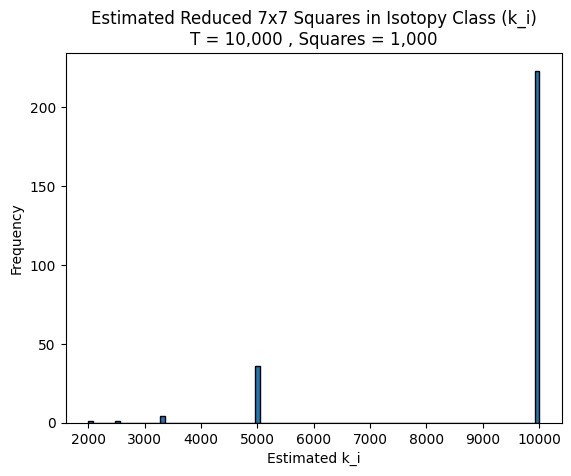

In [90]:
# Plot histogram
plt.hist(ki_estimates_7x7, bins=100, edgecolor='black')
plt.xlabel("Estimated k_i")
plt.ylabel("Frequency")
plt.title(f"Estimated Reduced 7x7 Squares in Isotopy Class (k_i)\nT = 10,000 , Squares = 1,000")
plt.show()

In [7]:
ki_estimates_8x8 = estimate_ki_distribution(8,1000,50000)
# Filter out inf
ki_estimates_8x8 = np.array(ki_estimates_8x8)
ki_estimates_8x8 = ki_estimates_8x8[np.isfinite(ki_estimates_8x8)]

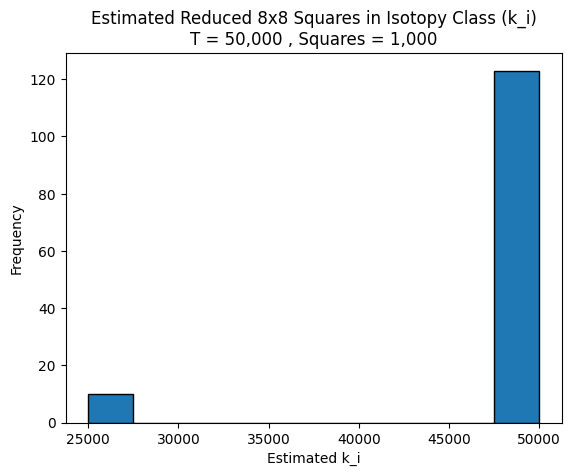

In [8]:
# Plot histogram
plt.hist(ki_estimates_8x8, bins=10, edgecolor='black')
plt.xlabel("Estimated k_i")
plt.ylabel("Frequency")
plt.title(f"Estimated Reduced 8x8 Squares in Isotopy Class (k_i)\nT = 50,000 , Squares = 1,000")
plt.show()